In [2]:
# ============================================================
# INDUSTRIAL EQUIPMENT FAILURE PREDICTION
# Gaussian Naive Bayes - Complete ML Project
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)






In [3]:
df = pd.read_excel("machine_failure_data.csv.xlsx")

print("\n========== DATASET LOADED ==========")
print(df.head())


========== DATASET LOADED ==========
    Machine_ID           Timestamp  Temperature  Pressure  Vibration_Level  \
0  MACHINE_001 2025-01-01 00:00:00        56.23    106.00             3.75   
1  MACHINE_002 2025-01-01 00:10:00        36.45    179.39             8.02   
2  MACHINE_003 2025-01-01 00:20:00        64.44    432.66             4.38   
3  MACHINE_004 2025-01-01 00:30:00        23.28    407.56             4.77   
4  MACHINE_005 2025-01-01 00:40:00        27.35    197.15             8.81   

   Humidity  Power_Consumption  Failure_Status  
0     77.50              92.06               0  
1     74.75              30.30               0  
2     62.55              38.74               0  
3     38.96              58.70               0  
4     50.49              35.34               1  


In [4]:
print("\n========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())

print("\n========== DATA TYPES ==========")
print(df.dtypes)

print("\n========== DATASET INFORMATION ==========")
df.info()



========== DATASET SHAPE ==========
(3000, 8)

========== COLUMN NAMES ==========
['Machine_ID', 'Timestamp', 'Temperature', 'Pressure', 'Vibration_Level', 'Humidity', 'Power_Consumption', 'Failure_Status']

========== DATA TYPES ==========
Machine_ID                   object
Timestamp            datetime64[ns]
Temperature                 float64
Pressure                    float64
Vibration_Level             float64
Humidity                    float64
Power_Consumption           float64
Failure_Status                int64
dtype: object

========== DATASET INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Machine_ID         3000 non-null   object        
 1   Timestamp          3000 non-null   datetime64[ns]
 2   Temperature        3000 non-null   float64       
 3   Pressure           3000 non

In [5]:

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())
print("\n========== DUPLICATE ROWS ==========")
print("Number of duplicates:", df.duplicated().sum())


========== MISSING VALUES ==========
Machine_ID           0
Timestamp            0
Temperature          0
Pressure             0
Vibration_Level      0
Humidity             0
Power_Consumption    0
Failure_Status       0
dtype: int64

========== DUPLICATE ROWS ==========
Number of duplicates: 0


In [6]:
print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe())



========== STATISTICAL SUMMARY ==========
                           Timestamp  Temperature     Pressure  \
count                           3000   3000.00000  3000.000000   
mean   2025-01-11 09:54:59.999999744     50.20313   299.459657   
min              2025-01-01 00:00:00     20.02000   100.200000   
25%              2025-01-06 04:57:30     34.87000   199.017500   
50%              2025-01-11 09:55:00     50.68500   300.555000   
75%              2025-01-16 14:52:30     65.41500   402.857500   
max              2025-01-21 19:50:00     79.98000   499.740000   
std                              NaN     17.40254   116.434739   

       Vibration_Level     Humidity  Power_Consumption  Failure_Status  
count      3000.000000  3000.000000        3000.000000     3000.000000  
mean          5.056363    60.083897          52.291147        0.099333  
min           0.100000    30.010000           5.020000        0.000000  
25%           2.617500    45.537500          28.297500        0.000000

In [7]:
print("\n========== FAILURE DISTRIBUTION ==========")
print(df["Failure_Status"].value_counts())

print("\n========== FAILURE PERCENTAGE ==========")
print(
    df["Failure_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


========== FAILURE DISTRIBUTION ==========
Failure_Status
0    2702
1     298
Name: count, dtype: int64

========== FAILURE PERCENTAGE ==========
Failure_Status
0    90.07
1     9.93
Name: proportion, dtype: float64


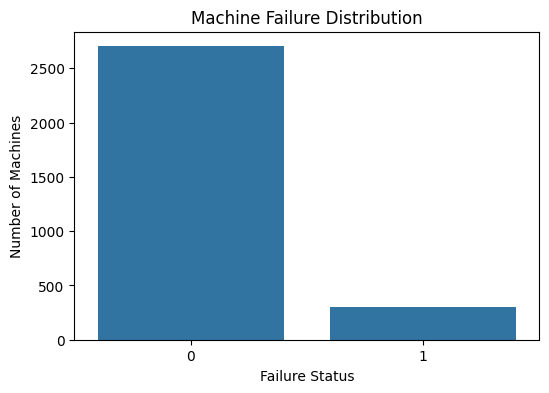

In [8]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x="Failure_Status",
    data=df
)

plt.title("Machine Failure Distribution")
plt.xlabel("Failure Status")
plt.ylabel("Number of Machines")
plt.show()


In [9]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [10]:
df["Hour"] = df["Timestamp"].dt.hour
df["Day"] = df["Timestamp"].dt.day
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek
df["Month"] = df["Timestamp"].dt.month


In [11]:
numeric_features = [
    "Temperature",
    "Pressure",
    "Vibration_Level",
    "Humidity",
    "Power_Consumption"
]

print("\n========== NUMERICAL FEATURES ==========")
print(df[numeric_features].describe())



========== NUMERICAL FEATURES ==========
       Temperature     Pressure  Vibration_Level     Humidity  \
count   3000.00000  3000.000000      3000.000000  3000.000000   
mean      50.20313   299.459657         5.056363    60.083897   
std       17.40254   116.434739         2.846718    17.249262   
min       20.02000   100.200000         0.100000    30.010000   
25%       34.87000   199.017500         2.617500    45.537500   
50%       50.68500   300.555000         5.055000    59.665000   
75%       65.41500   402.857500         7.570000    74.962500   
max       79.98000   499.740000        10.000000    89.950000   

       Power_Consumption  
count        3000.000000  
mean           52.291147  
std            27.369495  
min             5.020000  
25%            28.297500  
50%            52.520000  
75%            75.827500  
max            99.990000  


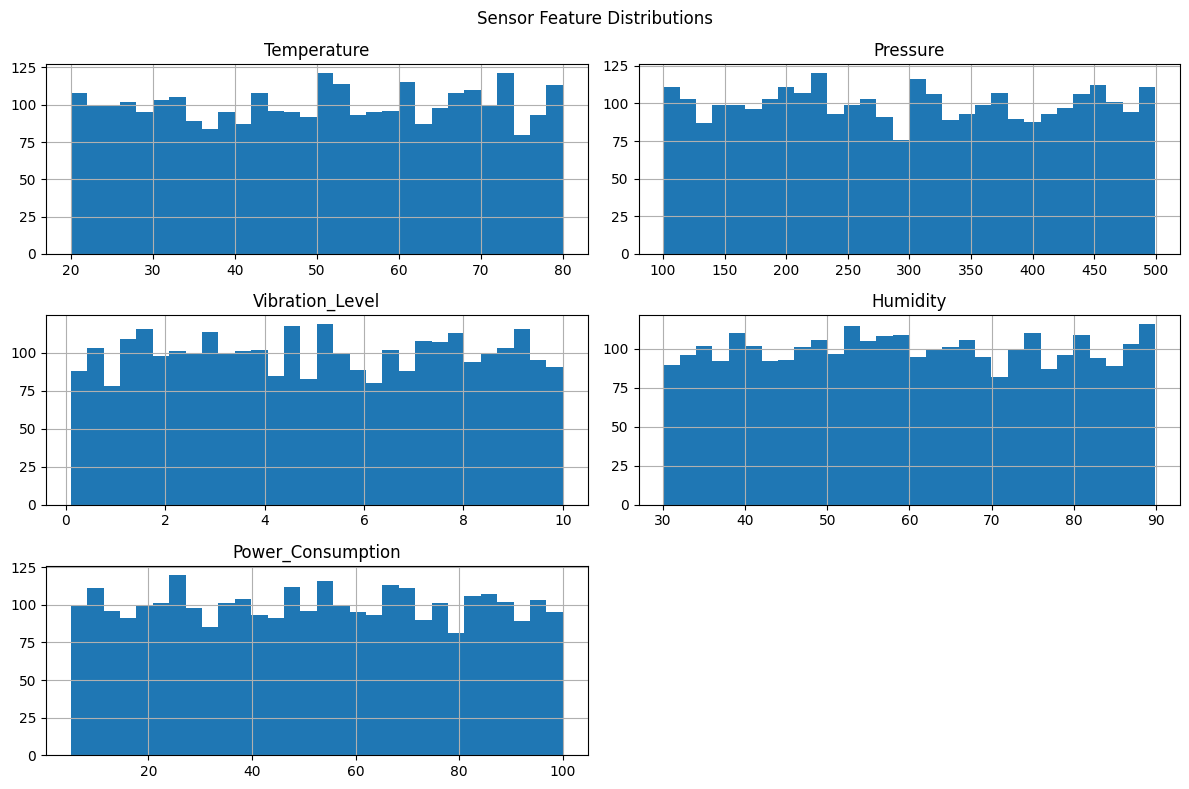

In [12]:
df[numeric_features].hist(
    figsize=(12, 8),
    bins=30
)

plt.suptitle("Sensor Feature Distributions")
plt.tight_layout()
plt.show()


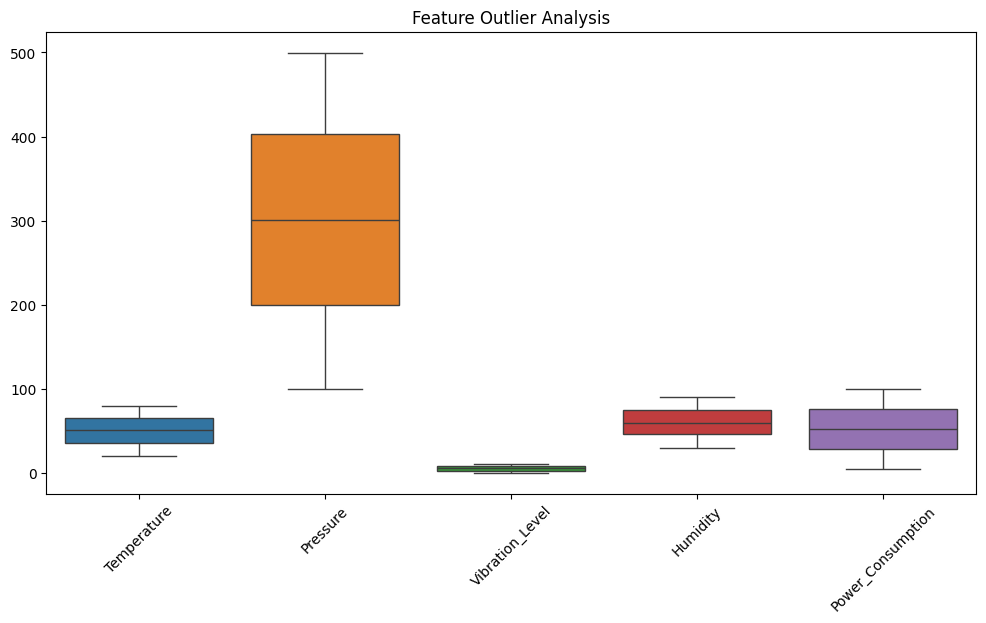

In [13]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[numeric_features]
)

plt.title("Feature Outlier Analysis")
plt.xticks(rotation=45)
plt.show()


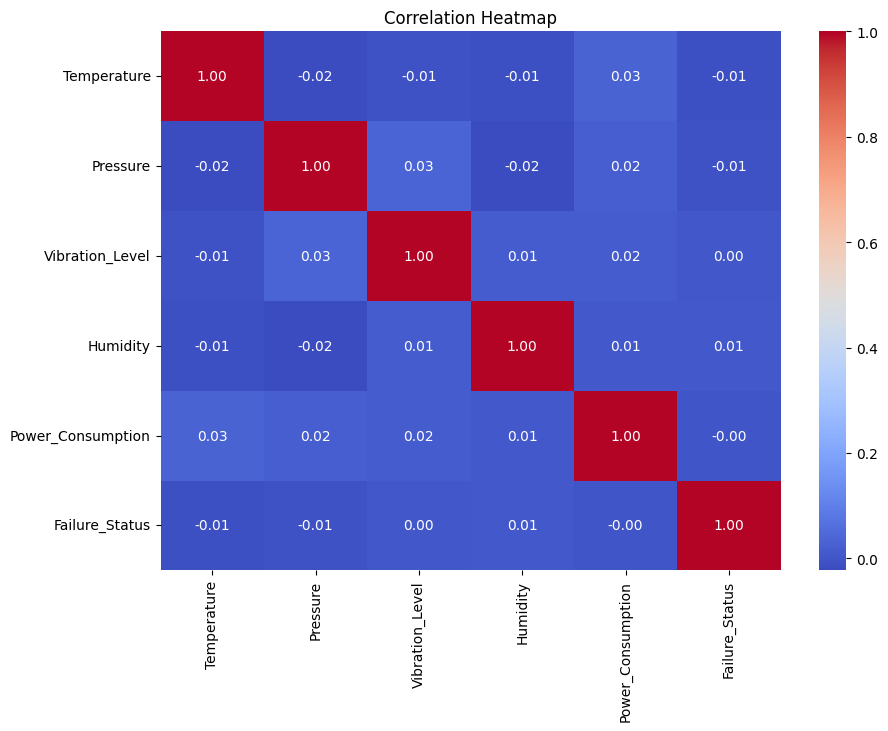

In [14]:
plt.figure(figsize=(10, 7))

correlation = df[
    numeric_features + ["Failure_Status"]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [15]:
print("\n========== AVERAGE SENSOR VALUES BY FAILURE STATUS ==========")

print(
    df.groupby("Failure_Status")[numeric_features].mean()
)


========== AVERAGE SENSOR VALUES BY FAILURE STATUS ==========
                Temperature    Pressure  Vibration_Level   Humidity  \
Failure_Status                                                        
0                 50.271828  299.745433         5.052261  60.033705   
1                 49.580235  296.868490         5.093557  60.538993   

                Power_Consumption  
Failure_Status                     
0                       52.298886  
1                       52.220973  


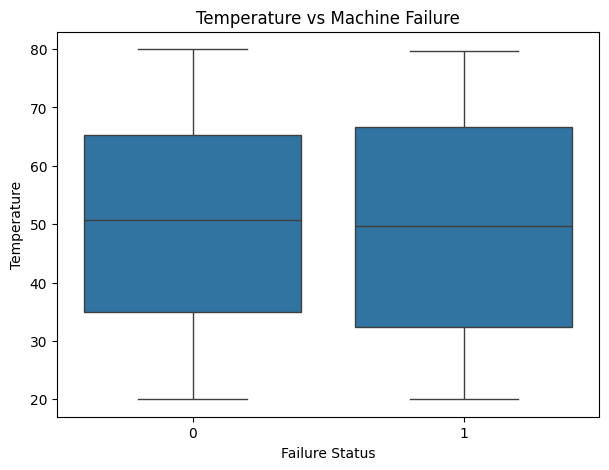

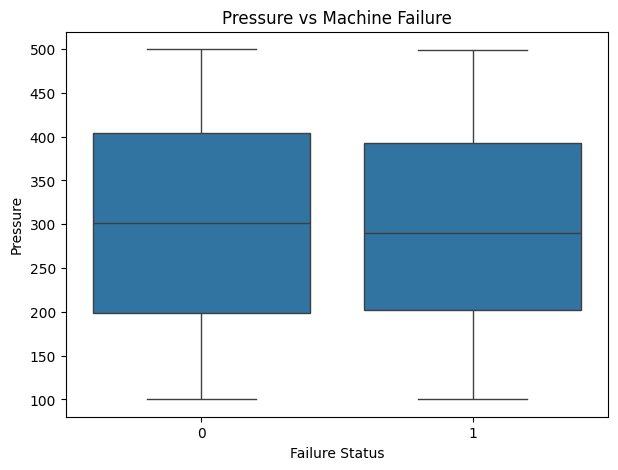

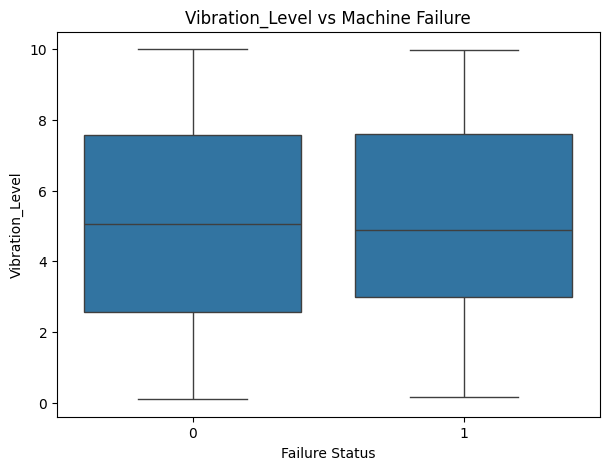

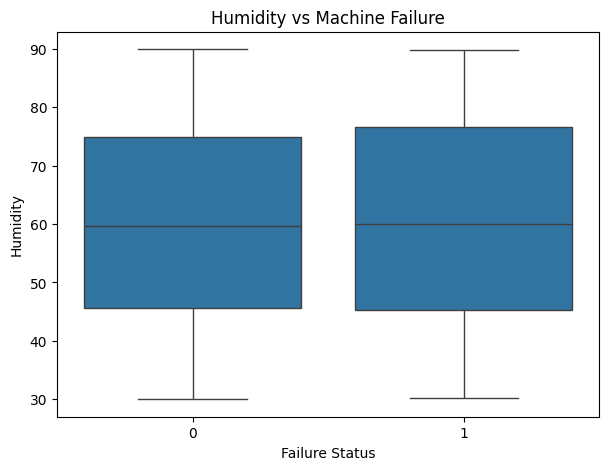

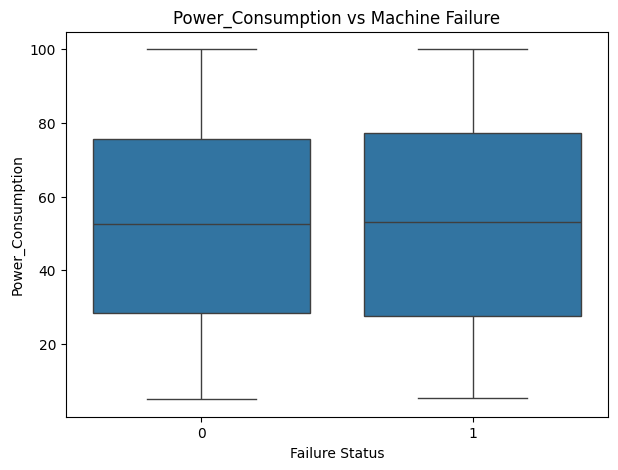

In [16]:
for feature in numeric_features:

    plt.figure(figsize=(7, 5))

    sns.boxplot(x="Failure_Status",y=feature,data=df)
    plt.title(f"{feature} vs Machine Failure")
    plt.xlabel("Failure Status")
    plt.ylabel(feature)
    plt.show()


In [19]:
df_model = df.drop(columns=["Machine_ID", "Timestamp"])
X = df_model.drop(columns=["Failure_Status"])
y = df_model["Failure_Status"]
print("\n========== FEATURES ==========")
print(X.columns.tolist())
print("\n========== TARGET ==========")
print("Failure_Status")




========== FEATURES ==========
['Temperature', 'Pressure', 'Vibration_Level', 'Humidity', 'Power_Consumption', 'Hour', 'Day', 'DayOfWeek', 'Month']

========== TARGET ==========
Failure_Status


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("\n========== TRAIN/TEST SHAPE ==========")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)




========== TRAIN/TEST SHAPE ==========
X_train: (2400, 9)
X_test : (600, 9)
y_train: (2400,)
y_test : (600,)


In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [22]:
gnb = GaussianNB()
gnb.fit(X_train_scaled,y_train)





GaussianNB()

In [23]:
y_pred_gnb = gnb.predict(X_test_scaled)

In [24]:
gnb_accuracy = accuracy_score(y_test,y_pred_gnb)

gnb_precision = precision_score(y_test,y_pred_gnb,zero_division=0)

gnb_recall = recall_score(y_test,y_pred_gnb,zero_division=0)

gnb_f1 = f1_score(y_test,y_pred_gnb,zero_division=0)
print("\n========================================")
print("     GAUSSIAN NAIVE BAYES RESULTS")
print("========================================")

print("Accuracy :", round(gnb_accuracy, 4))
print("Precision:", round(gnb_precision, 4))
print("Recall   :", round(gnb_recall, 4))
print("F1 Score :", round(gnb_f1, 4))



     GAUSSIAN NAIVE BAYES RESULTS
Accuracy : 0.9
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


In [25]:

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        y_pred_gnb,
        zero_division=0
    )
)



========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       540
           1       0.00      0.00      0.00        60

    accuracy                           0.90       600
   macro avg       0.45      0.50      0.47       600
weighted avg       0.81      0.90      0.85       600




========== CONFUSION MATRIX ==========
[[540   0]
 [ 60   0]]


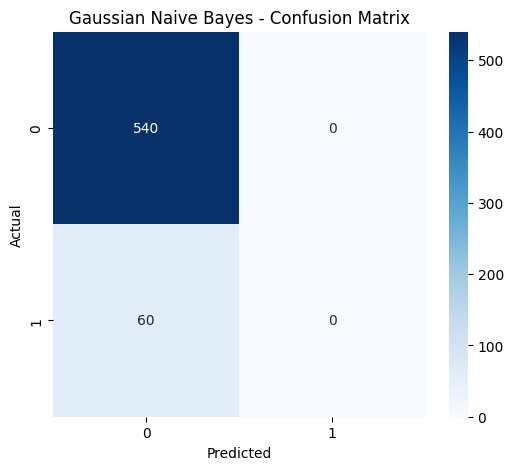

In [27]:
cm = confusion_matrix(y_test,y_pred_gnb)
print("\n========== CONFUSION MATRIX ==========")
print(cm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
lr = LogisticRegression(random_state=42,max_iter=1000)
lr.fit(X_train_scaled,y_train)
y_pred_lr = lr.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test,y_pred_lr)
lr_precision = precision_score(y_test,y_pred_lr,zero_division=0)
lr_recall = recall_score(y_test,y_pred_lr,zero_division=0)
lr_f1 = f1_score(y_test,y_pred_lr,zero_division=0)


In [31]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test,y_pred_rf)
rf_precision = precision_score(y_test,y_pred_rf,zero_division=0)

rf_recall = recall_score(y_test,y_pred_rf,zero_division=0)
rf_f1 = f1_score(y_test,y_pred_rf,zero_division=0)



In [32]:
results = pd.DataFrame({

    "Model": ["Gaussian Naive Bayes","Logistic Regression","Random Forest"],

    "Accuracy": [gnb_accuracy,lr_accuracy,rf_accuracy],

    "Precision": [gnb_precision,lr_precision, rf_precision],

    "Recall": [gnb_recall,lr_recall,rf_recall],

    "F1 Score": [gnb_f1,lr_f1,rf_f1]
})


print("\n========================================")
print("          MODEL COMPARISON")
print("========================================")

print(results.round(4))




          MODEL COMPARISON
                  Model  Accuracy  Precision  Recall  F1 Score
0  Gaussian Naive Bayes       0.9        0.0     0.0       0.0
1   Logistic Regression       0.9        0.0     0.0       0.0
2         Random Forest       0.9        0.0     0.0       0.0


In [34]:
joblib.dump(gnb,"machine_failure_gaussian_nb.pkl")
joblib.dump(scaler,"machine_failure_scaler.pkl")
print("\nModel and scaler saved successfully.")


Model and scaler saved successfully.


In [38]:

print("========================================")
print("     MACHINE FAILURE PREDICTION")
print("========================================")

temperature = float(input("Enter Temperature: "))
pressure = float(input("Enter Pressure: "))
vibration = float(input("Enter Vibration Level: "))
humidity = float(input("Enter Humidity: "))
power = float(input("Enter Power Consumption: "))
new_machine = pd.DataFrame({

    "Temperature": [temperature],

    "Pressure": [pressure],

    "Vibration_Level": [vibration],

    "Humidity": [humidity],

    "Power_Consumption": [power],

    # Timestamp-derived features
    # We use the current date/time for a new observation.

    "Hour": [pd.Timestamp.now().hour],

    "Day": [pd.Timestamp.now().day],

    "DayOfWeek": [pd.Timestamp.now().dayofweek],

    "Month": [pd.Timestamp.now().month]
})
new_machine = new_machine[
    X.columns
]


# ============================================================
# 34. SCALE NEW MACHINE DATA
# ============================================================

new_machine_scaled = scaler.transform(
    new_machine
)


# ============================================================
# 35. PREDICT MACHINE FAILURE
# ============================================================

prediction = gnb.predict(
    new_machine_scaled
)


# ============================================================
# 36. GET FAILURE PROBABILITY
# ============================================================

probability = gnb.predict_proba(
    new_machine_scaled
)

failure_probability = probability[0][1] * 100


# ============================================================
# 37. DISPLAY FINAL RESULT
# ============================================================

print("\n========================================")

if prediction[0] == 1:

    print("MACHINE FAILURE PREDICTED")

else:

    print(" MACHINE IS OPERATING NORMALLY")


print(
    f"Failure Probability: {failure_probability:.2f}%"
)

print("========================================")


     MACHINE FAILURE PREDICTION
Enter Temperature: 24
Enter Pressure: 28
Enter Vibration Level: 79
Enter Humidity: 49
Enter Power Consumption: 35

 MACHINE IS OPERATING NORMALLY
Failure Probability: 0.00%
